# Week 2: Vectors, Span, and Linear Independence
*TBIL Sections: EV1–EV6  |  Topics: Linear combinations, spanning sets, independence, basis*

---
> **How to use:**  
> • Click **`Copy to Drive`** at the top to save your own editable copy  
> • Run each cell with **`Shift + Enter`** or the ▶ button  
> • Complete the **Exercises** section at the bottom  


## Setup — Run This First


Run this cell before anything else.


In [2]:
import numpy as np
from sympy import Matrix
import matplotlib.pyplot as plt
print('Libraries loaded!')


Libraries loaded!


## Part 1: Testing Span with RREF (EV1, EV2)


**Key idea:** Is **b** in span{**v₁**, **v₂**, **v₃**}?  
This is the same as asking: does **c₁v₁ + c₂v₂ + c₃v₃ = b** have a solution?  
Set up the augmented matrix **[v₁ | v₂ | v₃ | b]** and find RREF.  
- If the **last column gets a pivot** → inconsistent → **b is NOT in the span**  
- If the **last column has no pivot** → **b IS in the span**  


In [3]:
v1 = Matrix([1, 0, 2])
v2 = Matrix([0, 1, -1])
v3 = Matrix([2, 1, 3])
b  = Matrix([3, 2, 7])

aug = Matrix.hstack(v1, v2, v3, b)
print('Augmented matrix [v1|v2|v3|b]:')
print(aug)

rref, pivots = aug.rref()
print('\nRREF:')
print(rref)
print('Pivot columns:', pivots)

if 3 in pivots:
    print('\n=> b is NOT in span{v1,v2,v3} (last column has a pivot)')
else:
    print('\n=> b IS in span{v1,v2,v3}')


Augmented matrix [v1|v2|v3|b]:
Matrix([[1, 0, 2, 3], [0, 1, 1, 2], [2, -1, 3, 7]])

RREF:
Matrix([[1, 0, 2, 0], [0, 1, 1, 0], [0, 0, 0, 1]])
Pivot columns: (0, 1, 3)

=> b is NOT in span{v1,v2,v3} (last column has a pivot)


## Part 2: Visualizing Span in R² (EV2)
 ( You can also refer to the code in the book )


Let's *see* what span means geometrically in **R²**.

- **Independent vectors** → span fills the whole plane  
- **Dependent vectors** (one is a multiple of the other) → span is just a line  


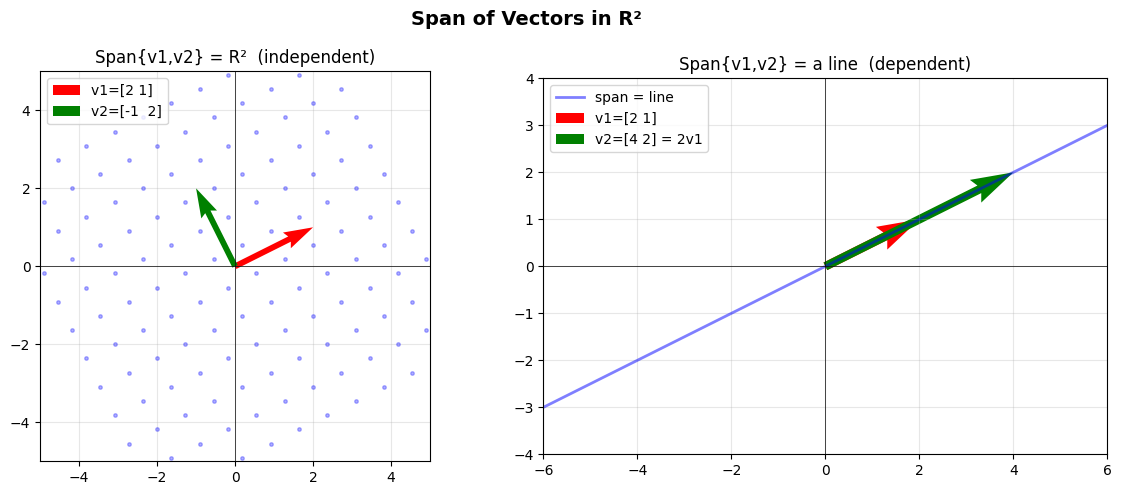

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Span of Vectors in R²', fontsize=14, fontweight='bold')

# --- Independent vectors: span = all of R² ---
ax = axes[0]
ax.set_title('Span{v1,v2} = R²  (independent)')
v1_2d = np.array([2, 1])
v2_2d = np.array([-1, 2])
for c1 in np.linspace(-2, 2, 12):
    for c2 in np.linspace(-2, 2, 12):
        pt = c1*v1_2d + c2*v2_2d
        ax.plot(pt[0], pt[1], 'b.', alpha=0.3, markersize=5)
ax.quiver(0,0,v1_2d[0],v1_2d[1],angles='xy',scale_units='xy',scale=1,color='red',width=0.015,label=f'v1={v1_2d}')
ax.quiver(0,0,v2_2d[0],v2_2d[1],angles='xy',scale_units='xy',scale=1,color='green',width=0.015,label=f'v2={v2_2d}')
ax.set_xlim(-5,5); ax.set_ylim(-5,5)
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.grid(True,alpha=0.3); ax.legend(); ax.set_aspect('equal')

# --- Dependent vectors: span = a line ---
ax = axes[1]
ax.set_title('Span{v1,v2} = a line  (dependent)')
v1_dep = np.array([2, 1])
v2_dep = np.array([4, 2])  # = 2*v1
t = np.linspace(-3, 3, 100)
line = np.outer(t, v1_dep)
ax.plot(line[:,0], line[:,1], 'b-', lw=2, alpha=0.5, label='span = line')
ax.quiver(0,0,v1_dep[0],v1_dep[1],angles='xy',scale_units='xy',scale=1,color='red',width=0.015,label=f'v1={v1_dep}')
ax.quiver(0,0,v2_dep[0],v2_dep[1],angles='xy',scale_units='xy',scale=1,color='green',width=0.015,label=f'v2={v2_dep} = 2v1')
ax.set_xlim(-6,6); ax.set_ylim(-4,4)
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.grid(True,alpha=0.3); ax.legend(); ax.set_aspect('equal')

plt.tight_layout()
plt.show()


## Part 3: Checking Linear Independence (EV4)


3.1 Checking Linear Independence by Defining a Function

A set {**v₁**, ..., **vₖ**} is **linearly independent** if the only solution to  
**c₁v₁ + ... + cₖvₖ = 0** is the trivial one (all cᵢ = 0).  

**How to check in Python:** Build the matrix [v₁|...|vₖ] and find RREF.  
- If **every column has a pivot** → **independent**  
- If **some column is free** → **dependent** (that vector is redundant)  


In [5]:
def check_independence(vectors, names=None):
  #Create matrix with vectors as columns
    M = Matrix(np.column_stack(vectors).tolist())
    # Reduce to row echelon form
    rref, pivots = M.rref()
    n_cols = M.cols

    # Create names if not provided
    if names is None:
        names = [f'v{i+1}' for i in range(n_cols)]

    # Display results
    print(f'Matrix [{", ".join(names)}]:')
    print(M)
    print(f'RREF:\n{rref}')
    print(f'Pivot columns: {pivots}')

    # Check independence
    if len(pivots) == n_cols:
        print('=> LINEARLY INDEPENDENT')
    else:
        free = [i for i in range(n_cols) if i not in pivots]
        print(f'=> LINEARLY DEPENDENT (column(s) {free} are free/redundant)')
    return len(pivots) == n_cols

# Example 1: Standard basis vectors (independent)
print('--- Example 1 ---')
check_independence([[1,0,0],[0,1,0],[0,0,1]], ['e1','e2','e3'])

# Example 2: Dependent set
print('\n--- Example 2 ---')
check_independence([[1,2,3],[4,5,6],[7,8,9]])


--- Example 1 ---
Matrix [e1, e2, e3]:
Matrix([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
RREF:
Matrix([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
Pivot columns: (0, 1, 2)
=> LINEARLY INDEPENDENT

--- Example 2 ---
Matrix [v1, v2, v3]:
Matrix([[1, 4, 7], [2, 5, 8], [3, 6, 9]])
RREF:
Matrix([[1, 0, -1], [0, 1, 2], [0, 0, 0]])
Pivot columns: (0, 1)
=> LINEARLY DEPENDENT (column(s) [2] are free/redundant)


False

3.2 Checking Linear Independence by Ananlysis ( Checking for pivots in every column )

In [6]:
M = Matrix([[1, 2, 3],
            [4,5,6],
            [7,8,9]])
rref_3_2, pivots_3_2 = M.rref()
print('RREF:')
print(rref_3_2)
print('Pivot columns:', pivots_3_2)

RREF:
Matrix([[1, 0, -1], [0, 1, 2], [0, 0, 0]])
Pivot columns: (0, 1)


## Part 4: Basis and Dimension (EV5, EV6)


The **pivot columns** of a matrix form a **basis** for its column space.  
The **number of pivots = rank = dimension** of the column space.  


In [ ]:
v1 = Matrix([1, 2, 0, -1])
v2 = Matrix([0, 1, 1,  2])
v3 = Matrix([2, 5, 1,  0])
v4 = Matrix([1, 0, -2, -5])

M = Matrix.hstack(v1, v2, v3, v4)
print('Matrix M = [v1|v2|v3|v4]:')
print(M)

rref, pivots = M.rref()
print(f'\nRREF:\n{rref}')
print(f'Pivot columns: {pivots}')
print(f'Dimension of span = {len(pivots)}')
print('Basis = pivot columns of ORIGINAL matrix:', [f'v{p+1}' for p in pivots])


## Part 5: Exercises — Your Turn! ✏️


Complete the exercises below.

**Exercise 1:** Is `b = [3, -1, 5]` in span{`[1,0,2]`, `[0,1,-1]`}?  
Set up the augmented matrix and interpret the RREF.


In [ ]:
# Exercise 1
v1_ex = Matrix([1, 0, 2])
v2_ex = Matrix([0, 1, -1])
b_ex  = Matrix([3, -1, 5])

# aug = Matrix.hstack(...)  # complete this
# rref, pivots = aug.rref()
# print(rref)
# Conclusion: b is / is not in the span because ...


**Exercise 2:** Are these vectors linearly independent?  
`v1=[1,-1,2]`, `v2=[3,1,0]`, `v3=[5,-1,4]`  
If dependent, which vector is a linear combination of the others?


In [ ]:
# Exercise 2 -- use the check_independence() function from Part 3
# check_independence([v1, v2, v3])


**Exercise 3:** Find a basis for the column space of A and state its dimension.  
```
A = [[1, 0, 2, 3],
     [0, 1,-1, 2],
     [0, 0, 0, 0]]
```


In [ ]:
# Exercise 3
A_ex3 = Matrix([[1, 0, 2, 3],
                [0, 1,-1, 2],
                [0, 0, 0, 0]])
rref_ex3, pivots_ex3 = A_ex3.rref()
print('Pivot columns:', pivots_ex3)
print('Dimension:', len(pivots_ex3))
print('Basis vectors (original columns):')
for p in pivots_ex3:
    print(f'  Column {p+1}:', list(A_ex3.col(p).T))
